# Clasificación de Imágenes de Malaria

Este notebook implementa un sistema de clasificación binaria para detectar la presencia de malaria en imágenes de frotis sanguíneos. Utilizamos TensorFlow y Keras para construir una red neuronal convolucional (CNN), siguiendo buenas prácticas de procesamiento, división de datos, entrenamiento, evaluación y guardado del modelo.

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall, AUC
import os

Esto forzará a Keras/TensorFlow a usar ejecución eager, lo cual es necesario para que .fit() funcione correctamente con modelos cargados desde archivos en muchos entornos (como Google Colab o algunos servidores personalizados).

In [3]:
tf.config.run_functions_eagerly(True)

## Carga del Dataset

Usamos el conjunto de datos `malaria` disponible en `tensorflow_datasets`. Este dataset contiene imágenes de frotis sanguíneos clasificadas como infectadas o no infectadas.

In [4]:
dataset, info = tfds.load('malaria', with_info=True, as_supervised=True)
dataset = dataset['train']
info

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

## Preprocesamiento de Imágenes

Redimensionamos todas las imágenes a 128x128 píxeles y normalizamos los valores de píxel al rango [0, 1].

In [5]:
IMG_SIZE = 128

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

### Es importante ver si el dataset está balanceado

En este caso lo está, pero en los dataset de salud suele haber muchos más sanos que enfermos. Habría que dar un peso distinto a cada categoría en función de su escasez. También dependerá de si queremos más especificidad o más sensibilidad.

In [6]:
# prompt: Ver cuántas fotografías tenemos de cada categoría (label)

label_counts = {}
for image, label in dataset:
    label_value = label.numpy()  # Get the integer value of the tensor
    if label_value not in label_counts:
        label_counts[label_value] = 0
    label_counts[label_value] += 1

print("Number of images per label:")
# Map label values to their names (assuming 0 is 'uninfected' and 1 is 'parasitized')
label_names = info.features['label'].names
for label_value, count in label_counts.items():
    print(f"{label_names[label_value]}: {count}")

Number of images per label:
uninfected: 13779
parasitized: 13779


## División del Dataset

Dividimos el dataset en entrenamiento (80%), validación (10%) y prueba (10%).

In [7]:
dataset_size = tf.data.experimental.cardinality(dataset).numpy()
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)

train_ds = dataset.take(train_size).shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)
val_test_ds = dataset.skip(train_size)
val_ds = val_test_ds.take(val_size).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = val_test_ds.skip(val_size).batch(32).prefetch(tf.data.AUTOTUNE)

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


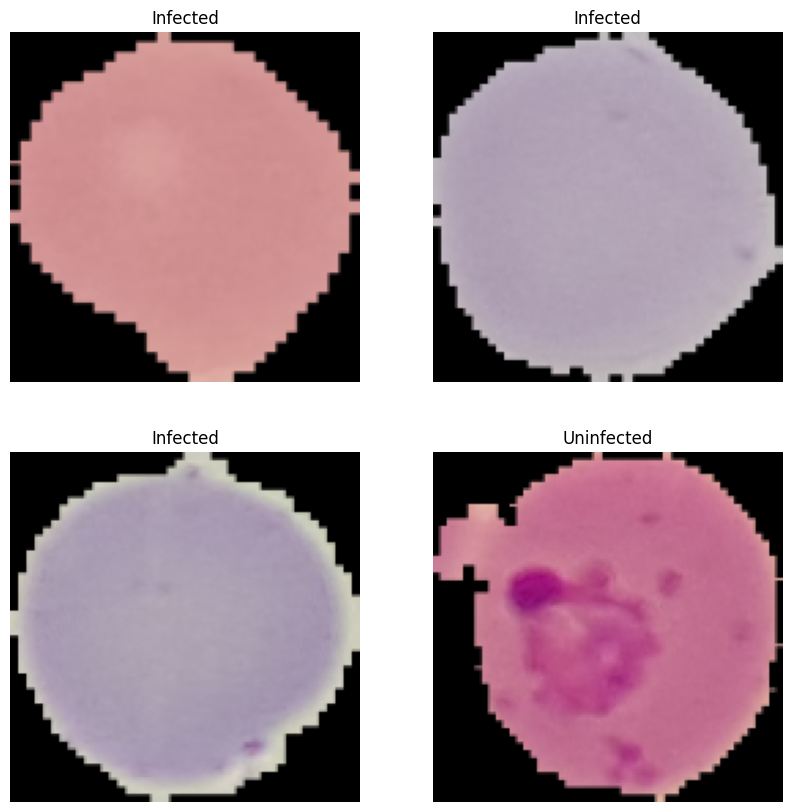

In [8]:
# prompt: Haz una visualización de 4 fotografías aleatorias procedentes del train, con sus labels correspondientes

import numpy as np

def show_random_images(dataset, num_images=4):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        # Get a random element from the dataset
        for image, label in dataset.take(1):
            plt.subplot(2, 2, i + 1)
            plt.imshow(image.numpy())
            plt.title("Infected" if label.numpy() == 1 else "Uninfected")
            plt.axis("off")
    plt.show()

# Display 4 random images from the training dataset
show_random_images(train_ds.unbatch()) # Unbatch to get individual images

## Arquitectura del Modelo

Utilizamos una red neuronal convolucional (CNN) con capas de normalización y dropout para mejorar la generalización. La salida es una probabilidad (clasificación binaria).

In [12]:
# Si /content/mejor_modelo.keras existe cargar el modelo, si no model=None
if os.path.exists('/content/mejor_modelo.keras'):
    model = tf.keras.models.load_model('/content/mejor_modelo.keras')
    print('Modelo cargado')
elif os.path.exists('/content/modelo_malaria_tf.keras'):
    model = tf.keras.models.load_model('/content/modelo_malaria_tf.keras')
    print('Modelo cargado')
else:
    model = None
    print('No se ha cargado ningún modelo')

Modelo cargado


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
if model is None:
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPool2D(),
        BatchNormalization(),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPool2D(),
        BatchNormalization(),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy', Precision(), Recall(), AUC()])

## Entrenamiento del Modelo

Entrenamos el modelo usando `EarlyStopping` para detener el entrenamiento si la validación deja de mejorar, y `ModelCheckpoint` para guardar el mejor modelo encontrado.

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('mejor_modelo.keras', save_best_only=True)
]

history = model.fit(train_ds, epochs=20, validation_data=val_ds, callbacks=callbacks)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 939s 1s/step - accuracy: 0.8690 - auc: 0.9536 - loss: 0.2795 - precision: 0.9204 - recall: 0.8116 - val_accuracy: 0.5031 - val_auc: 0.5265 - val_loss: 3.8273 - val_precision: 0.8966 - val_recall: 0.0187
Epoch 2/20
 12/689 ━━━━━━━━━━━━━━━━━━━━ 14:01 1s/step - accuracy: 0.8929 - auc: 0.9709 - loss: 0.2149 - precision: 0.8985 - recall: 0.9127

## Evaluación del Modelo

Evaluamos el modelo en el conjunto de prueba para obtener métricas finales de desempeño.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate predictions for the test set
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Uninfected', 'Infected'], yticklabels=['Uninfected', 'Infected'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# prompt: Obtener las métricas de desempeño

# Get the metrics from the model evaluation
test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")

## Guardado del Modelo

Guardamos el modelo entrenado para uso futuro con `model.save()`.

In [ ]:
model.save('modelo_malaria_tf.keras')